<div class="alert alert-success"><h1>Using a Pretrained Model for Image Segmentation in Python</h1></div>

In this tutorial, you'll learn how to use a pretrained **YOLO** model for **image segmentation** in Python. Image segmentation is one of the most common tasks in computer vision. It involves partitioning an image at the pixel level so that each pixel is assigned to a specific class or object instance. The output of a segmentation model includes pixel-wise masks for each detected region, class labels, bounding boxes, and confidence scores indicating how certain the model is about each prediction. This approach is especially useful when you need to know not just what objects are present but also the precise shape and extent of each object.

## Learning Objectives
By the end of this tutorial, you will know:
+ How to load and prepare a YOLO image segmentation model for inference
+ How to run segmentation inference and inspect raw mask outputs
+ How to overlay masks, bounding boxes, and labels on the original image

## Prerequisites
Before we begin, please ensure that you have:
+ A working knowledge of Python, including variables, functions, loops, and basic object-oriented programming.
+ A Python (version 3.x) environment with the `ultralytics`, `opencv-python`, `matplotlib`, `numpy`, and `Pillow` packages installed.

<hr>

## YOLO ("You Only Look Once")
YOLO includes segmentation-capable models that combine detection with pixel-level mask prediction. By framing segmentation as an extension of detection, YOLO generates bounding boxes, class labels, and per-instance masks in one pass. YOLO image segmentation models are trained on the **COCO** dataset and are optimized for real-time mask inference.

Visit "https://docs.ultralytics.com/tasks/segment/" for details on available YOLO segmentation models, their performance, and recommended use cases.

## 1. Load the Pretrained Model
Import the YOLO class and load a pretrained segmentation model. The weights will be downloaded automatically if not present.

In [1]:
from ultralytics import YOLO
model = YOLO("yolo11n-seg.pt")

100%|██████████| 5.90M/5.90M [00:00<00:00, 74.4MB/s]


The model is now ready for image segmentation. We can choose other available models depending on your accuracy and speed requirements.

## 2. Specify the Input Image
Next, we define the path to the image file we want to process. 

In [2]:
image_path = "images/56886693.jpeg"

Let's display the image so we can visually confirm that the correct file is referenced.

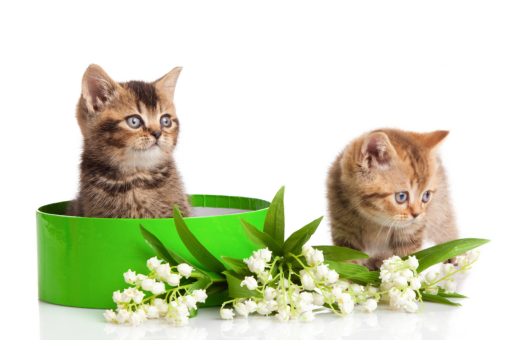

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.show()

## 3. Run Image Segmentation on the Input Image
Now we pass the image path to the model. This automatically resizes the image to the model’s expected dimensions (640 × 640 by default), normalizes pixel values, and batches the input (if we pass several images). 

In [4]:
results = model(image_path)


image 1/1 /Users/shengxiangli/Documents/programmation/Machine_Learning/deep-learning-with-python-convolutional-neural-networks-3930067/src/images/56886693.jpeg: 448x640 2 cats, 100.8ms
Speed: 22.9ms preprocess, 100.8ms inference, 13.3ms postprocess per image at shape (1, 3, 448, 640)


The output is a summary showing the resized dimensions of the input image, number of detected masks per class, and timing information for preprocessing, inference, and postprocessing.

## 4. Parse and Display the Segmentations
Next, we loop through the results to extract bounding box coordinates, labels, and confidence scores.

In [5]:
for result in results:
    boxes = result.boxes
    for box in boxes:
        cls_id = int(box.cls)
        conf = box.conf.item()
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        print(f"Detected class {cls_id} with confidence {conf:.2f} at coordinates ({x1:.2f}, {y1:.2f}, {x2:.2f}, {y2:.2f})")

Detected class 15 with confidence 0.77 at coordinates (3100.85, 1166.09, 4435.98, 2570.72)
Detected class 15 with confidence 0.56 at coordinates (546.33, 531.35, 1837.35, 2065.47)


YOLO provides a built‑in `plot()` method to draw boxes and labels directly on the image, as well as overlay a segmentation mask. We use the method to get an annotated array, convert from BGR to RGB color, then display it.

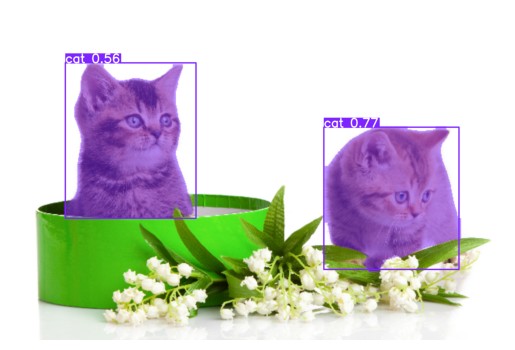

In [6]:
import cv2
im_bgr = result.plot()
im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(im_rgb)
plt.axis('off')
plt.show()

In this tutorial, you learned how to use a pretrained YOLO segmentation model to perform image segmentation in Python, demonstrating its speed and ease of use for generating precise pixel-level masks. Some potential next steps include batch-segmenting folders of images, applying segmentation to video streams, or fine-tuning a YOLO segmentation model on your own dataset.